In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from random import randint
sns.set()
import os
import gc

In [2]:
gc.collect()

0

### Loading Data

In [4]:
healthy_dirs = ["GSM" + str(3587996 + i) for i in range(0, 8)]
others_dirs = ["GSM" + str(3588004 + i) for i in range(0, 2)]

samples = {"healthy": {}, "unhealthy": {}, "others": {}}

for sample_dir in os.listdir("../datasets/GSE116256"):
    if sample_dir.endswith(".csv"):
        continue
    for file in os.listdir("../datasets/GSE116256/" + sample_dir):
        # print(file)
        sample = file.split(".")[0].split("_")[-1].split("-")

        sample_type = (
            "healthy"
            if sample_dir in healthy_dirs
            else "others"
            if sample_dir in others_dirs
            else "unhealthy"
        )

        sample_code = sample[1] if len(sample) > 1 else "/"

        sample_file = (
            "dem"
            if file.endswith(".dem.txt")
            else "nanopore"
            if file.endswith(".nanopore.txt")
            else "anno"
        )

        if sample[0] not in samples[sample_type].keys():
            samples[sample_type][sample[0]] = {
                sample_code: {
                    sample_file: pd.read_csv(
                        "../datasets/GSE116256/" + sample_dir + "/" + file,
                        sep="\t",
                        index_col=0,
                        header=0,
                    )
                }
            }

        elif sample_code not in samples[sample_type][sample[0]].keys():
            samples[sample_type][sample[0]][sample_code] = {
                sample_file: pd.read_csv(
                    "../datasets/GSE116256/" + sample_dir + "/" + file,
                    sep="\t",
                    index_col=0,
                    header=0,
                )
            }

        else:
            samples[sample_type][sample[0]][sample_code][sample_file] = pd.read_csv(
                "../datasets/GSE116256/" + sample_dir + "/" + file,
                sep="\t",
                index_col=0,
                header=0,
            )

In [8]:
samples['unhealthy']['AML921A']['D0']['dem']

,AML921A-D0_AAAAAGGGTTAT,AML921A-D0_AAAACAATCGGT,AML921A-D0_AAAACCACAAGC,AML921A-D0_AAAACCCATTCG,AML921A-D0_AAAACCTTCCGA,AML921A-D0_AAAACGGCAGGC,AML921A-D0_AAAAGATCTGGA,AML921A-D0_AAAAGGCGACCT,AML921A-D0_AAAAGTGGCCGC,AML921A-D0_AAAATAATGCGT,...,AML921A-D0_TTTTCCGTCCCG,AML921A-D0_TTTTCGCGGTAN,AML921A-D0_TTTTCGGATTAT,AML921A-D0_TTTTCGTCCGAC,AML921A-D0_TTTTCGTCGTTA,AML921A-D0_TTTTCTCCTGAC,AML921A-D0_TTTTCTTCATTA,AML921A-D0_TTTTGCTTCCCT,AML921A-D0_TTTTGGACGCTA,AML921A-D0_TTTTTAAACGCT
Gene,,,,,,,,,,,,,,,,,,,,,
A1BG,0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
A1BG-AS1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A1CF,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A2M,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A2M-AS1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYG11A,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ZYG11B,0,0,0,3,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,0,1
ZYX,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [4]:
all_unhealthies = None

for sample in samples:
    if sample == "unhealthy":
        for sample_case in samples[sample]:
            for sample_code in samples[sample][sample_case]:
                for sample_file in samples[sample][sample_case][sample_code]:
                    if sample_file == 'dem':
                        print(sample, sample_case, sample_code, sample_file)
                        if all_unhealthies is None:
                            all_unhealthies = samples[sample][sample_case][sample_code][sample_file]
                        else:
                            all_unhealthies = pd.concat([all_unhealthies, samples[sample][sample_case][sample_code][sample_file]], axis=1)
                        print('added!')
                        

unhealthy AML1012 D0 dem
added!
unhealthy AML210A D0 dem
added!
unhealthy AML314 D0 dem
added!
unhealthy AML314 D31 dem
added!
unhealthy AML328 D0 dem
added!
unhealthy AML328 D113 dem
added!
unhealthy AML328 D171 dem
added!
unhealthy AML328 D29 dem
added!
unhealthy AML329 D0 dem
added!
unhealthy AML329 D20 dem
added!
unhealthy AML329 D37 dem
added!
unhealthy AML371 D0 dem
added!
unhealthy AML371 D34 dem
added!
unhealthy AML419A D0 dem
added!
unhealthy AML420B D0 dem
added!
unhealthy AML420B D14 dem
added!
unhealthy AML420B D35 dem
added!
unhealthy AML475 D0 dem
added!
unhealthy AML475 D29 dem
added!
unhealthy AML556 D0 dem
added!
unhealthy AML556 D15 dem
added!
unhealthy AML556 D31 dem
added!
unhealthy AML707B D0 dem
added!
unhealthy AML707B D113 dem
added!
unhealthy AML707B D18 dem
added!
unhealthy AML707B D41 dem
added!
unhealthy AML707B D97 dem
added!
unhealthy AML722B D0 dem
added!
unhealthy AML722B D49 dem
added!
unhealthy AML870 D0 dem
added!
unhealthy AML870 D14 dem
added!
unhea

In [5]:
all_healthies = None

for sample in samples:
    if sample == "healthy":
        for sample_case in samples[sample]:
            for sample_code in samples[sample][sample_case]:
                for sample_file in samples[sample][sample_case][sample_code]:
                    if sample_file == 'dem':
                        print(sample, sample_case, sample_code, sample_file)
                        if sample_code != '34p38n':
                            if all_healthies is None:
                                all_healthies = samples[sample][sample_case][sample_code][sample_file]
                            else:
                                all_healthies = pd.concat([all_healthies, samples[sample][sample_case][sample_code][sample_file]], axis=1)
                        else:
                            if all_healthies is None:
                                all_healthies = samples[sample][sample_case][sample_code][sample_file].sample(n=783, axis=1)
                                # all_healthies = samples[sample][sample_case][sample_code][sample_file]
                            else:
                                all_healthies = pd.concat([all_healthies, samples[sample][sample_case][sample_code][sample_file].sample(n=783, axis=1)], axis=1)
                                # all_healthies = pd.concat([all_healthies, samples[sample][sample_case][sample_code][sample_file]], axis=1)
                        print('added!')
                        

healthy BM1 / dem
added!
healthy BM2 / dem
added!
healthy BM3 / dem
added!
healthy BM4 / dem
added!
healthy BM5 34p dem
added!
healthy BM5 34p38n dem
added!


### Clustering

In [7]:
all_healthies

,BM1_AAAGTCTCAAAC,BM1_AAATTTCCATTG,BM1_AAGGTTCCATAA,BM1_ACACCGATAATG,BM1_ACACGTGCGCAA,BM1_ACGCTCTGGCCN,BM1_ACTCATATAATG,BM1_ACTCGGAGGCGN,BM1_ACTTGAGGCAAG,BM1_AGAGTTATACCG,...,BM5-34p38n_TTGAAACAAGCT,BM5-34p38n_ATTCATGCGACT,BM5-34p38n_CGATTTGCGAAT,BM5-34p38n_GCGGAGCTGGAC,BM5-34p38n_TATAGGCGGCAG,BM5-34p38n_TTGTATCCTCCC,BM5-34p38n_TGCTGCCCCCAT,BM5-34p38n_ATATCAAAGAGA,BM5-34p38n_CGGACGCAGCTT,BM5-34p38n_CATCTTTCCGAA
Gene,,,,,,,,,,,,,,,,,,,,,
A1BG,0,0,0,0,0,0,0,0,0,0,...,0,1,0,1,1,0,0,0,0,0
A1BG-AS1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A1CF,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A2M,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A2M-AS1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYG11A,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ZYG11B,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,0
ZYX,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


##### Determining the most variably expressed genes

In [8]:
from scipy.stats import norm
from sklearn.linear_model import LinearRegression
from statsmodels.distributions.empirical_distribution import ECDF
import statsmodels.api as sm 

In [9]:
target_dataset = all_healthies

In [10]:
E_mean_min = 0.1

In [11]:
target_dataset

,BM1_AAAGTCTCAAAC,BM1_AAATTTCCATTG,BM1_AAGGTTCCATAA,BM1_ACACCGATAATG,BM1_ACACGTGCGCAA,BM1_ACGCTCTGGCCN,BM1_ACTCATATAATG,BM1_ACTCGGAGGCGN,BM1_ACTTGAGGCAAG,BM1_AGAGTTATACCG,...,BM5-34p38n_CCGACTGCGCAG,BM5-34p38n_GCACGACATCTG,BM5-34p38n_TTGTGAGGCCGT,BM5-34p38n_CCCCATGGAGGA,BM5-34p38n_GTGACCGCGTGC,BM5-34p38n_CGGCTCATATTC,BM5-34p38n_GTGGCAATCGTT,BM5-34p38n_GTATATTTTGGC,BM5-34p38n_AGAAACGGATAT,BM5-34p38n_GCGCTCGTATAA
Gene,,,,,,,,,,,,,,,,,,,,,
A1BG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A1BG-AS1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A1CF,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A2M,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A2M-AS1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYG11A,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ZYG11B,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,3,0
ZYX,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
target_dataset = (target_dataset / target_dataset.sum(axis=0)) * 10000

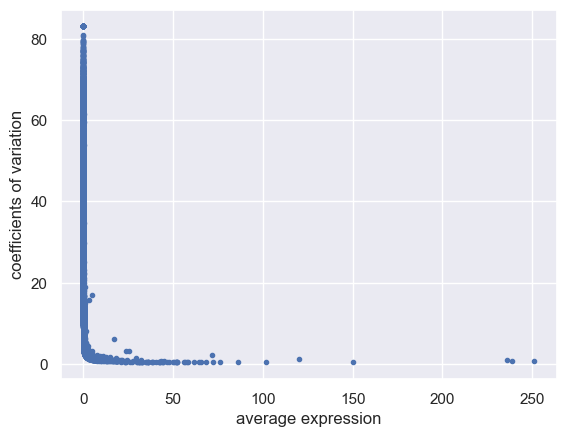

In [13]:
E_mean = target_dataset.mean(axis=1) 
E_cv = target_dataset.std(axis=1) / E_mean 

E_mean = E_mean[~E_cv.isna()].sort_values()  
E_cv = E_cv[E_mean.index]

plt.scatter(E_mean, E_cv, marker='.')
plt.xlabel('average expression')
plt.ylabel('coefficients of variation');

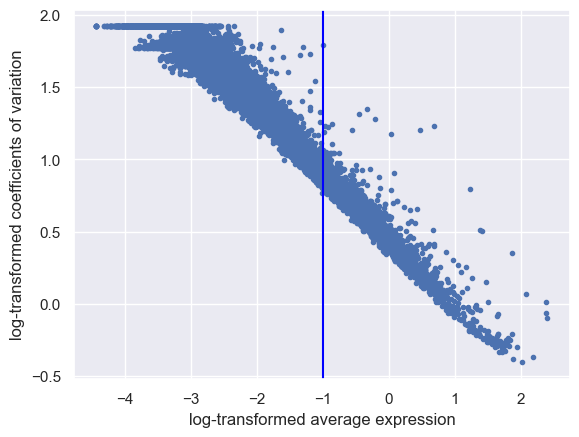

In [14]:
plt.scatter(np.log10(E_mean), np.log10(E_cv), marker='.')
plt.axvline(x=np.log10(E_mean_min), color='blue')
plt.xlabel('log-transformed average expression')
plt.ylabel('log-transformed coefficients of variation');

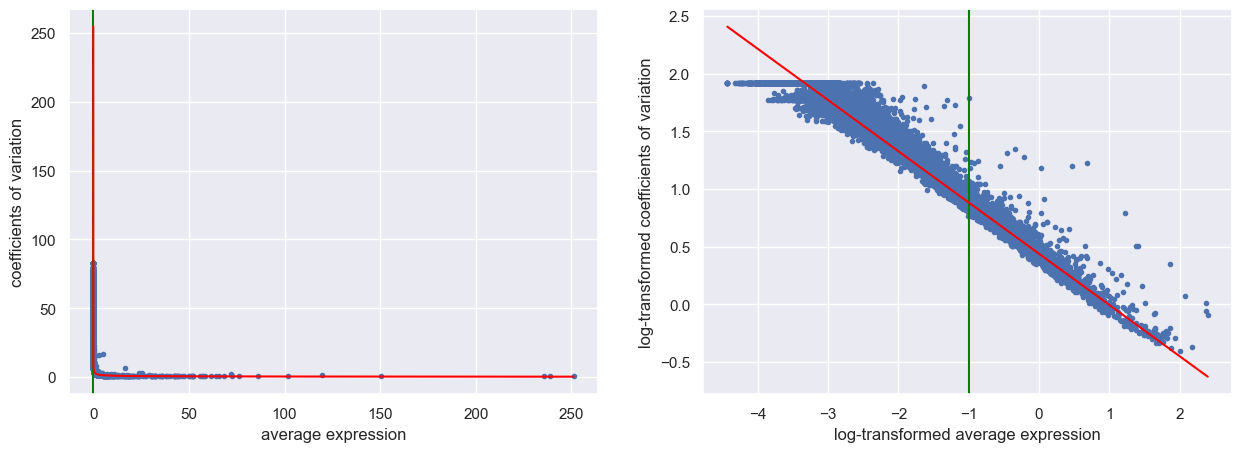

In [15]:
E_lm = LinearRegression().fit(np.log10(E_mean[E_mean >= E_mean_min]).values.reshape(-1, 1), np.log10(E_cv[E_mean >= E_mean_min]))

E_cv_predict = E_lm.predict(np.log10(E_mean).values.reshape(-1, 1))
fig, axis = plt.subplots(1, 2, figsize=(15, 5))

axis[0].scatter(E_mean, E_cv, marker='.')
axis[0].axvline(E_mean_min, color='green')
axis[0].plot(E_mean, 10 ** E_cv_predict, color='red')
axis[0].set_xlabel('average expression')
axis[0].set_ylabel('coefficients of variation')

axis[1].scatter(np.log10(E_mean), np.log10(E_cv), marker='.')
axis[1].axvline(x=np.log10(E_mean_min), color='green')
axis[1].plot(np.log10(E_mean), E_cv_predict, color='red')
axis[1].set_xlabel('log-transformed average expression')
axis[1].set_ylabel('log-transformed coefficients of variation');

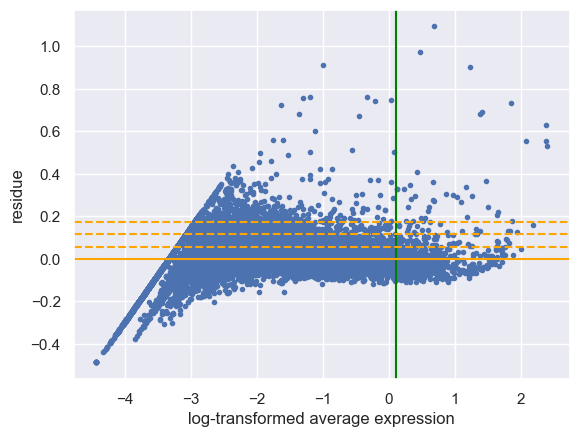

In [16]:
E_cv_residue = np.log10(E_cv) - E_cv_predict
plt.scatter(np.log10(E_mean), E_cv_residue, marker='.')
plt.axvline(x=E_mean_min, color='green')
plt.axhline(y=0, color='orange')
plt.axhline(y=E_cv_residue[E_mean >= E_mean_min].std() * 1, color='orange', linestyle='dashed')
plt.axhline(y=E_cv_residue[E_mean >= E_mean_min].std() * 2, color='orange', linestyle='dashed')
plt.axhline(y=E_cv_residue[E_mean >= E_mean_min].std() * 3, color='orange', linestyle='dashed')
plt.xlabel('log-transformed average expression')
plt.ylabel('residue');

In [17]:
# E_cv_residue[E_mean >= E_mean_min]

In [18]:
# pd.cut(E_cv_residue[E_mean >= E_mean_min], np.arange(-0.25, 1, 0.01))

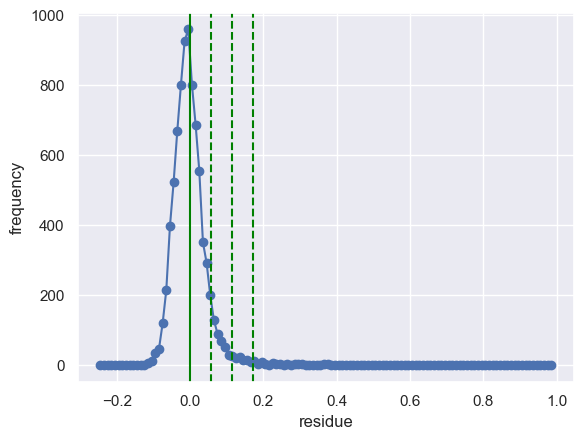

In [19]:
plt.plot(np.arange(-0.25+0.005, 1-0.005, 0.01), pd.cut(E_cv_residue[E_mean >= E_mean_min], np.arange(-0.25, 1, 0.01)).value_counts().sort_index().values, marker='o')
plt.axvline(x=0, color='green')
plt.axvline(x=E_cv_residue[E_mean >= E_mean_min].std() * 1, color='green', linestyle='dashed')
plt.axvline(x=E_cv_residue[E_mean >= E_mean_min].std() * 2, color='green', linestyle='dashed')
plt.axvline(x=E_cv_residue[E_mean >= E_mean_min].std() * 3, color='green', linestyle='dashed')
plt.xlabel('residue')
plt.ylabel('frequency');

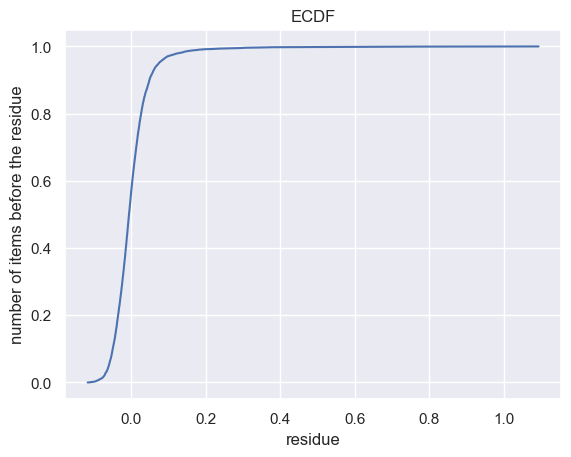

In [20]:
ecdf = ECDF(E_cv_residue[E_mean >= E_mean_min])
plt.plot(ecdf.x, ecdf.y)
plt.title('ECDF')
plt.ylabel('number of items before the residue');
plt.xlabel('residue');

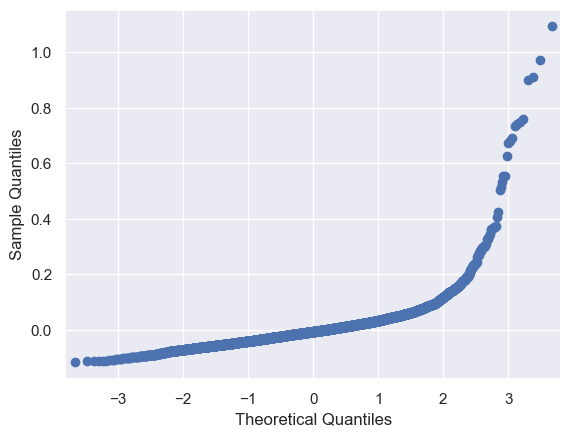

In [21]:
sm.qqplot(E_cv_residue[E_mean >= E_mean_min]);

In [22]:
E_cv_residue[E_mean >= E_mean_min].sort_values(ascending=False)

Gene
IGLL5      1.093511
JCHAIN     0.972278
CXCL12     0.909883
HBB        0.901018
HBA2       0.760497
             ...   
RPSAP58   -0.110864
NACA2     -0.111120
ATP5L2    -0.111403
UQCRHL    -0.111907
EIF5AL1   -0.117642
Length: 8185, dtype: float64

In [23]:
E_sd = 2

In [24]:
E_mean

Gene
LOC102723493      0.000037
TACR1             0.000037
MIR6797           0.000037
NPAS4             0.000037
MIR378J           0.000037
                   ...    
MALAT1          119.817892
RPS6            150.370417
RNA28S          235.771539
MTRNR2          238.711933
RNA18S          251.173272
Length: 20668, dtype: float64

In [25]:
variably_expressed_genes = E_cv_residue[E_mean >= E_mean_min].sort_values(ascending=False)
variably_expressed_genes_std = E_cv_residue[E_mean >= E_mean_min].std()

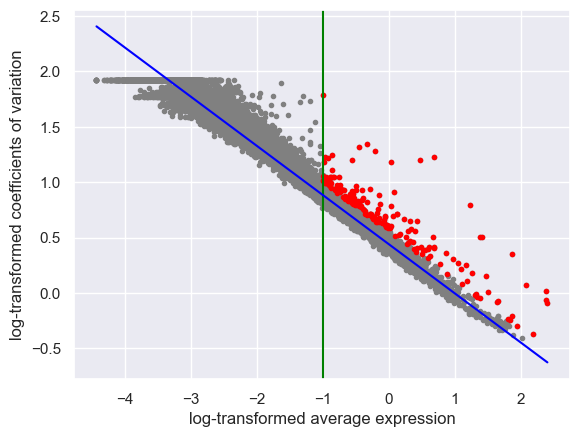

In [26]:
plt.scatter(np.log10(E_mean), np.log10(E_cv), marker='.', color='grey')
plt.scatter(np.log10(E_mean[variably_expressed_genes[variably_expressed_genes > E_sd * variably_expressed_genes_std].index]),
            np.log10(E_cv[variably_expressed_genes[variably_expressed_genes > E_sd * variably_expressed_genes_std].index]), marker='.', color='red')
plt.axvline(x=np.log10(E_mean_min), color='green')
plt.plot(np.log10(E_mean), E_cv_predict, color='blue')
plt.xlabel('log-transformed average expression') 
plt.ylabel('log-transformed coefficients of variation');

In [27]:
variably_expressed_genes[variably_expressed_genes > E_sd * variably_expressed_genes_std]

Gene
IGLL5     1.093511
JCHAIN    0.972278
CXCL12    0.909883
HBB       0.901018
HBA2      0.760497
            ...   
SLAMF7    0.116901
ARL4C     0.116659
IKZF2     0.116304
CAMK2D    0.116055
SP140     0.115770
Length: 192, dtype: float64

In [28]:
# remove cell cycle genes

cell_cycle_genes = ['ASPM', 'CENPE', 'CENPF', 'DLGAP5', 'MKI67', 'NUSAP1', 'PCLAF', 'STMN1', 'TOP2A', 'TUBB']

In [29]:
variably_expressed_genes_reduced = variably_expressed_genes[
    variably_expressed_genes[
        variably_expressed_genes > E_sd * variably_expressed_genes_std
    ].index.difference(cell_cycle_genes)
].sort_values(ascending=False)

variably_expressed_genes_reduced

Gene
IGLL5     1.093511
JCHAIN    0.972278
CXCL12    0.909883
HBB       0.901018
HBA2      0.760497
            ...   
SLAMF7    0.116901
ARL4C     0.116659
IKZF2     0.116304
CAMK2D    0.116055
SP140     0.115770
Length: 189, dtype: float64

In [30]:
variably_expressed_genes_reduced.to_csv('variably_expressed_genes.csv')

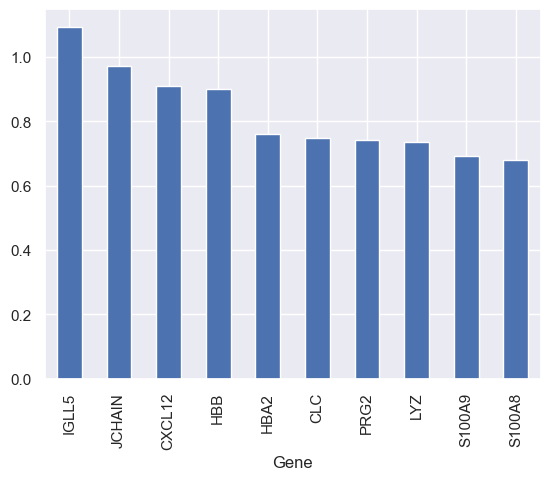

In [31]:
variably_expressed_genes_reduced.head(10).plot.bar();

In [32]:
variably_expressed_genes_reduced.shape

(189,)

In [33]:
target_dataset.loc[variably_expressed_genes_reduced.index, :]

,BM1_AAAGTCTCAAAC,BM1_AAATTTCCATTG,BM1_AAGGTTCCATAA,BM1_ACACCGATAATG,BM1_ACACGTGCGCAA,BM1_ACGCTCTGGCCN,BM1_ACTCATATAATG,BM1_ACTCGGAGGCGN,BM1_ACTTGAGGCAAG,BM1_AGAGTTATACCG,...,BM5-34p38n_CCGACTGCGCAG,BM5-34p38n_GCACGACATCTG,BM5-34p38n_TTGTGAGGCCGT,BM5-34p38n_CCCCATGGAGGA,BM5-34p38n_GTGACCGCGTGC,BM5-34p38n_CGGCTCATATTC,BM5-34p38n_GTGGCAATCGTT,BM5-34p38n_GTATATTTTGGC,BM5-34p38n_AGAAACGGATAT,BM5-34p38n_GCGCTCGTATAA
Gene,,,,,,,,,,,,,,,,,,,,,
IGLL5,0.000000,4.677268,0.000000,0.000000,0.000000,2.721088,4.490346,0.000000,0.000000,0.000000,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
JCHAIN,0.000000,1.559089,0.000000,0.000000,0.000000,0.000000,8.980692,0.000000,7.102273,0.000000,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CXCL12,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HBB,21.862702,29.622700,58.043118,25.553663,7.532011,27.210884,26.942075,25.429116,63.920455,41.928721,...,0.0,4.08998,1.428367,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HBA2,0.000000,3.118179,8.291874,17.035775,7.532011,0.000000,8.980692,0.000000,0.000000,4.192872,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SLAMF7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ARL4C,13.117621,0.000000,0.000000,0.000000,2.510670,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
IKZF2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.980692,0.000000,0.000000,0.000000,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
# data = target_dataset.loc[variably_expressed_genes_reduced.index, :].to_numpy()

# selected_features = feature_selection(data, thrs = 10)

# clusters = backSPIN(data, selected_features)

##### KNN

In [35]:
import numpy as np
import pandas as pd
import json
import os
from scipy.spatial.distance import cdist
from sklearn.neighbors import NearestNeighbors
from scipy.stats import zscore

In [36]:
X = np.log(target_dataset.loc[variably_expressed_genes_reduced.index, :] + 1)

X_cor = np.corrcoef(X.T)
print(X_cor.shape)

(6891, 6891)


In [37]:
k = 5
nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='ball_tree').fit(X_cor)
distances, indices = nbrs.kneighbors(X_cor)

X_knn = pd.DataFrame([(s, t, d) for s, t, d in zip(indices.flatten(), np.repeat(indices[:,0], k+1), distances.flatten())], columns=['source', 'target', 'distance'])

# make undirected
X_knn.loc[X_knn['source'] > X_knn['target'], ['source', 'target']] = X_knn.loc[X_knn['source'] > X_knn['target'], ['target', 'source']].values

X_knn.head()

,source,target,distance
0,0,0,0.000000
1,0,61,2.521005
2,0,55,2.931277
3,0,719,3.354478
4,0,557,3.373503


In [38]:
import networkx as nx
import community

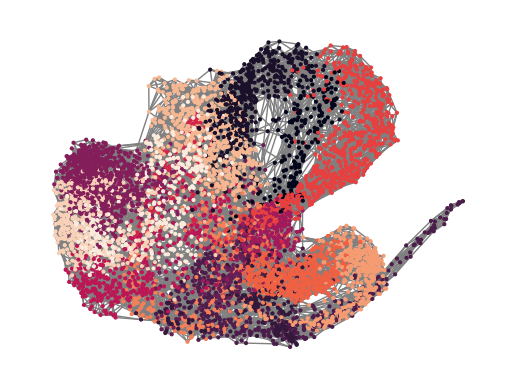

In [46]:
# Create a graph
G = nx.Graph()

# Add nodes
G.add_nodes_from(X_knn['source'].unique())

# Add edges
G.add_weighted_edges_from(tuple(x) for x in X_knn[['source', 'target', 'distance']].values if x[0] != x[1])

partition = community.best_partition(G)

# Draw the graph with colors based on communities
colors = [partition[node] for node in G.nodes()]


fig, ax = plt.subplots()

nx.draw(G, with_labels=False, node_size=4, node_color=colors, edge_color='gray', ax=ax)

##### T-SNE

In [40]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

In [41]:
X = np.log(target_dataset.loc[variably_expressed_genes_reduced.index, :] + 1)

In [47]:
X

,BM1_AAAGTCTCAAAC,BM1_AAATTTCCATTG,BM1_AAGGTTCCATAA,BM1_ACACCGATAATG,BM1_ACACGTGCGCAA,BM1_ACGCTCTGGCCN,BM1_ACTCATATAATG,BM1_ACTCGGAGGCGN,BM1_ACTTGAGGCAAG,BM1_AGAGTTATACCG,...,BM5-34p38n_CCGACTGCGCAG,BM5-34p38n_GCACGACATCTG,BM5-34p38n_TTGTGAGGCCGT,BM5-34p38n_CCCCATGGAGGA,BM5-34p38n_GTGACCGCGTGC,BM5-34p38n_CGGCTCATATTC,BM5-34p38n_GTGGCAATCGTT,BM5-34p38n_GTATATTTTGGC,BM5-34p38n_AGAAACGGATAT,BM5-34p38n_GCGCTCGTATAA
Gene,,,,,,,,,,,,,,,,,,,,,
IGLL5,0.000000,1.736470,0.000000,0.000000,0.000000,1.314016,1.702991,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
JCHAIN,0.000000,0.939652,0.000000,0.000000,0.000000,0.000000,2.300652,0.000000,2.092145,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CXCL12,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HBB,3.129507,3.421742,4.078268,3.279168,2.143825,3.339708,3.330134,3.274466,4.173163,3.759541,...,0.0,1.627274,0.887219,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HBA2,0.000000,1.415411,2.229140,2.892357,2.143825,0.000000,2.300652,0.000000,0.000000,1.647287,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SLAMF7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ARL4C,2.647424,0.000000,0.000000,0.000000,1.255807,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
IKZF2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.300652,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [42]:
tsne = TSNE(n_components=3, perplexity=30, n_iter=5000, random_state=0)
tsne_results = tsne.fit_transform(X.T)

In [43]:
clustered_results = KMeans(n_clusters=15, n_init='auto').fit_predict(tsne_results)

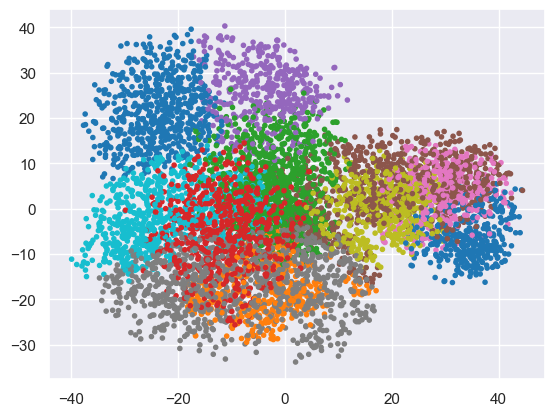

In [44]:
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], marker='.', c=clustered_results, cmap='tab10');

In [45]:
import plotly.express as px

fig = px.scatter_3d(x=tsne_results[:, 0], y=tsne_results[:, 1],
                    z=tsne_results[:, 2], color=clustered_results)

fig.show();